--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        10000 non-null  int64  
 1   Menstrual_Irregularity     10000 non-null  int64  
 2   Chronic_Pain_Level         10000 non-null  float64
 3   Hormone_Level_Abnormality  10000 non-null  int64  
 4   Infertility                10000 non-null  int64  
 5   BMI                        10000 non-null  float64
 6   Diagnosis                  10000 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 547.0 KB
None

--- Descriptive Statistics ---


,Age,Menstrual_Irregularity,Chronic_Pain_Level,Hormone_Level_Abnormality,Infertility,BMI,Diagnosis
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,33.692300,0.697500,5.030619,0.591100,0.298300,23.052865,0.407900
std,9.205308,0.459364,1.983955,0.491655,0.457535,3.891615,0.491469
min,18.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000
25%,26.000000,0.000000,3.671697,0.000000,0.000000,20.329327,0.000000
50%,34.000000,1.000000,5.035825,1.000000,0.000000,23.036315,0.000000
75%,42.000000,1.000000,6.396854,1.000000,1.000000,25.712923,1.000000
max,49.000000,1.000000,10.000000,1.000000,1.000000,37.146127,1.000000


C:\Users\HaadiyaH\AppData\Local\Temp\ipykernel_16244\2463861662.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df, palette='viridis')


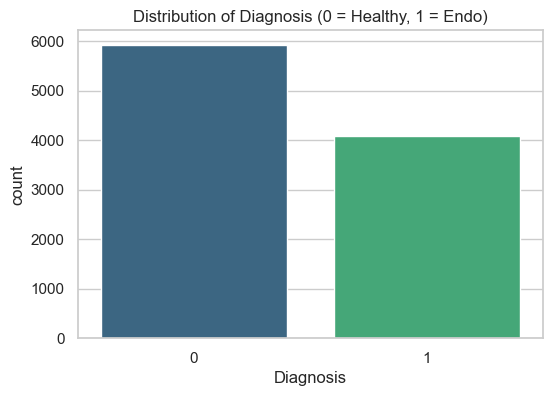

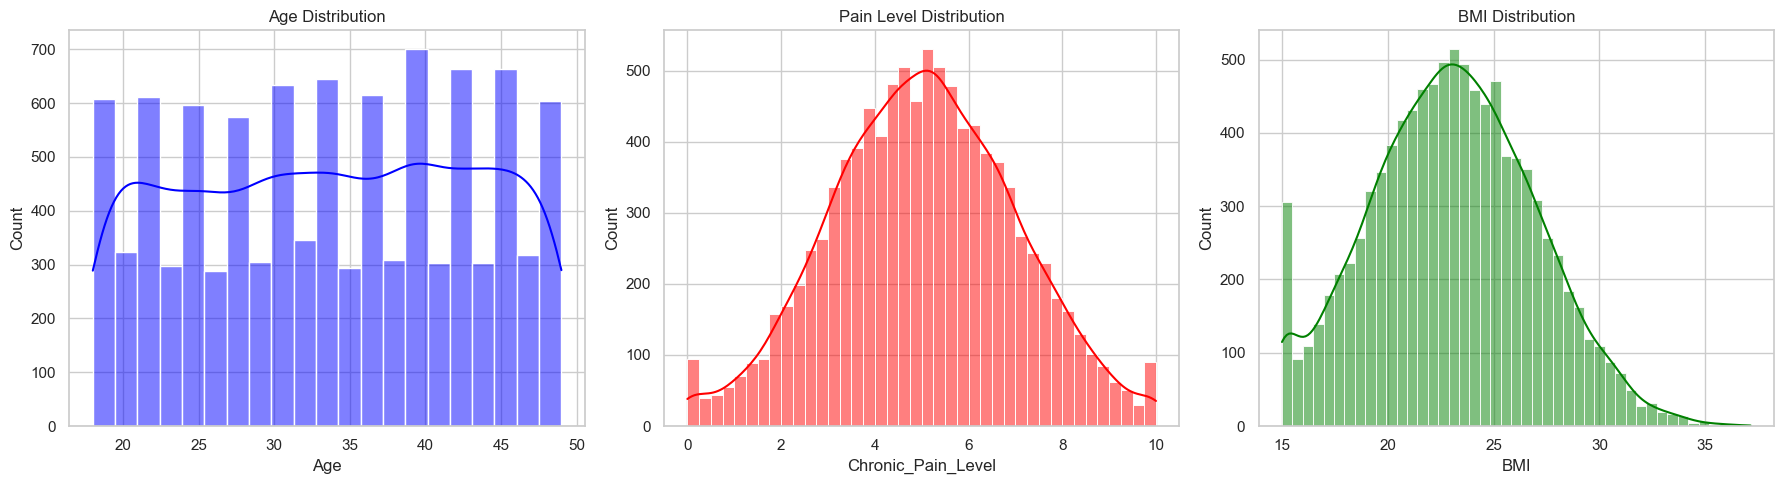

C:\Users\HaadiyaH\AppData\Local\Temp\ipykernel_16244\2463861662.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='Diagnosis', data=df, ax=axes[i], palette='magma')
C:\Users\HaadiyaH\AppData\Local\Temp\ipykernel_16244\2463861662.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='Diagnosis', data=df, ax=axes[i], palette='magma')
C:\Users\HaadiyaH\AppData\Local\Temp\ipykernel_16244\2463861662.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='Diagnosis', data=df, ax=axes[i], palette='magma')


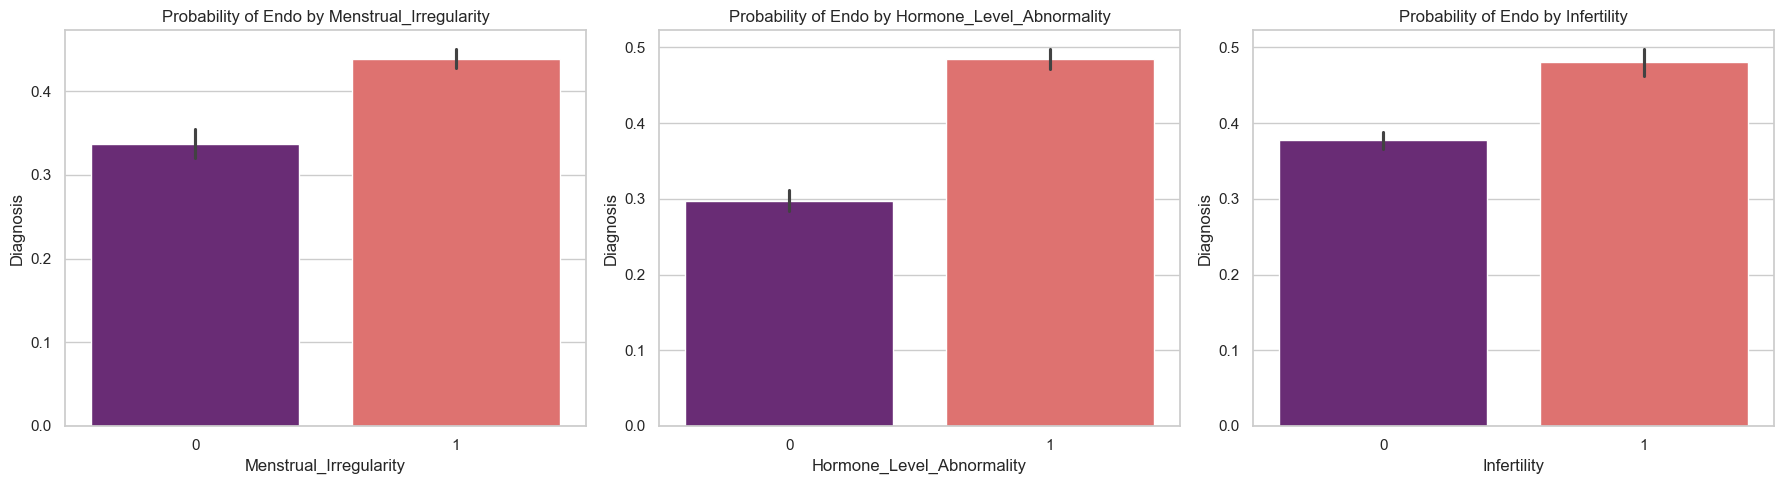

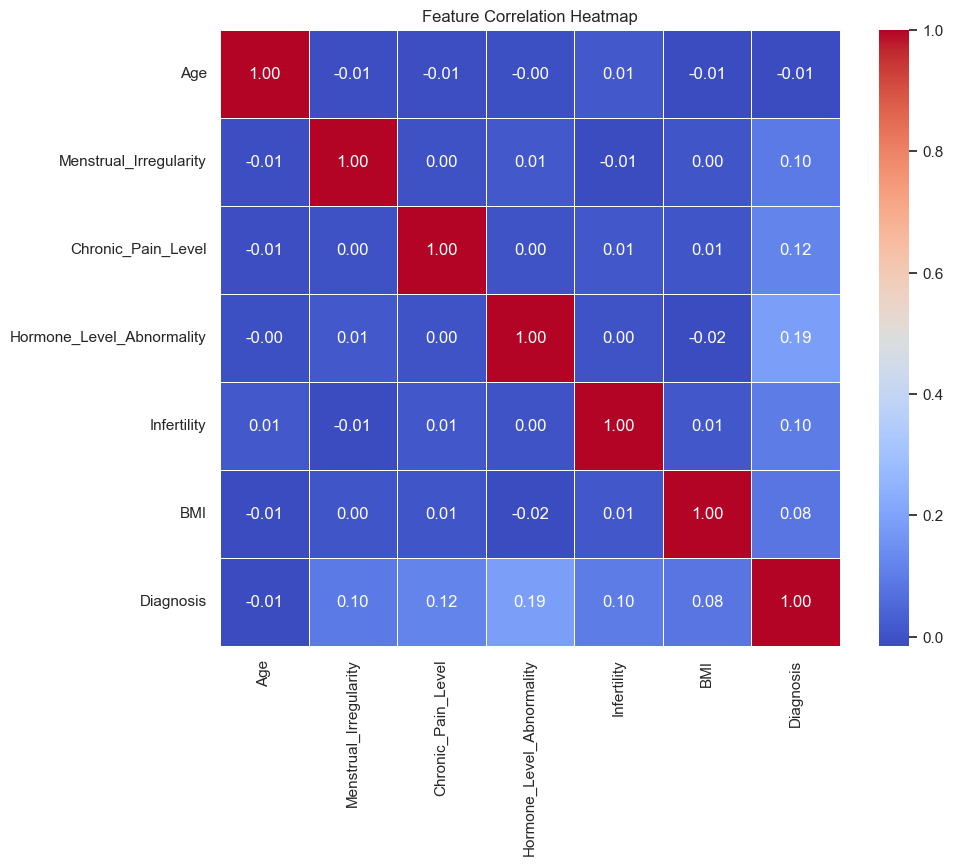

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
file_path = r"C:\Users\HaadiyaH\Desktop\Data\structured_endometriosis_data.csv"
df = pd.read_csv(file_path)

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# --- STEP 1: Statistical Summary ---
print("--- Dataset Info ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
display(df.describe())

# --- STEP 2: Target Class Balance ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Diagnosis', data=df, palette='viridis')
plt.title('Distribution of Diagnosis (0 = Healthy, 1 = Endo)')
plt.show()

# --- STEP 3: Distribution of Numerical Features ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='blue').set_title('Age Distribution')
sns.histplot(df['Chronic_Pain_Level'], kde=True, ax=axes[1], color='red').set_title('Pain Level Distribution')
sns.histplot(df['BMI'], kde=True, ax=axes[2], color='green').set_title('BMI Distribution')
plt.tight_layout()
plt.show()

# --- STEP 4: Bivariate Analysis (Symptoms vs Diagnosis) ---
# How do binary symptoms affect the outcome?
binary_features = ['Menstrual_Irregularity', 'Hormone_Level_Abnormality', 'Infertility']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(binary_features):
    sns.barplot(x=feature, y='Diagnosis', data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'Probability of Endo by {feature}')

plt.tight_layout()
plt.show()

# --- STEP 5: Correlation Analysis ---
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

🚀 Optimized RF Accuracy: 0.6070
📈 Optimized RF AUC-ROC: 0.6538
Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 50, 'n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.57      0.63      1184
           1       0.51      0.66      0.58       816

    accuracy                           0.61      2000
   macro avg       0.61      0.61      0.60      2000
weighted avg       0.63      0.61      0.61      2000



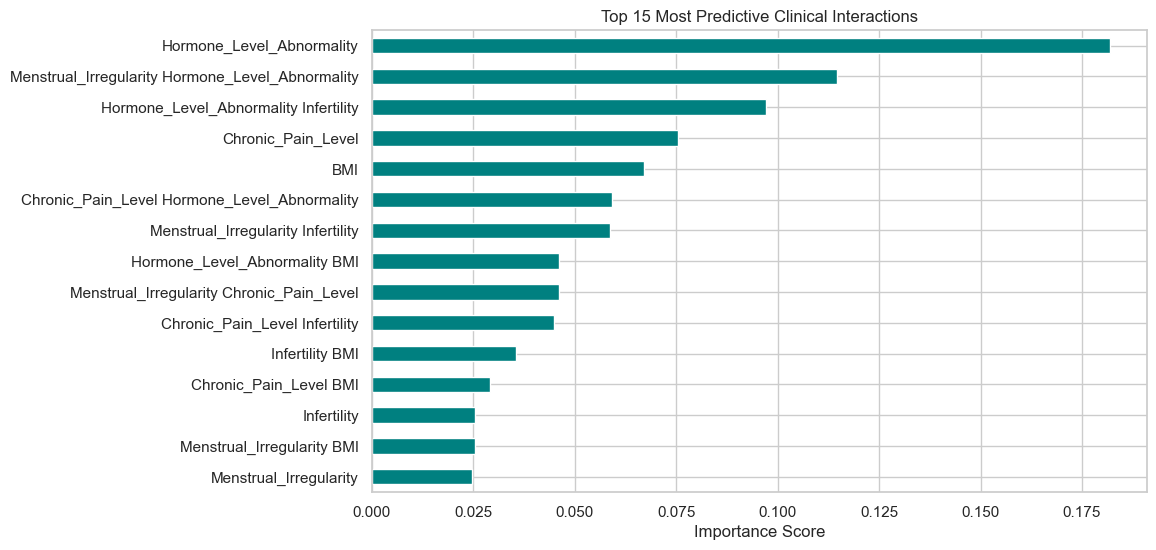

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

# 1. LOAD DATA
# Replace with your actual file path
df = pd.read_csv(r'C:\Users\HaadiyaH\Desktop\Data\structured_endometriosis_data.csv')

X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# 2. SPLIT & SCALE (Prevents NameError)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. CREATE INTERACTION FEATURES
# Captures clinical relationships (e.g., Age x Pain Level)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_int = poly.fit_transform(X_train_scaled)
X_test_int = poly.transform(X_test_scaled)

# 4. RANDOM FOREST SETUP
# 'balanced_subsample' weights classes within each bootstrap sample for better results
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced_subsample')

# Hyperparameter Grid
rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 8, 12],
    'min_samples_leaf': [10, 20, 50],
    'max_features': ['sqrt', 'log2']
}

# 5. GRID SEARCH (Optimizing for AUC-ROC)
rf_grid = GridSearchCV(rf_model, rf_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train_int, y_train)

# 6. EVALUATION
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_int)
y_prob_rf = best_rf.predict_proba(X_test_int)[:, 1]

print(f"🚀 Optimized RF Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"📈 Optimized RF AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Best Params: {rf_grid.best_params_}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# 7. FEATURE IMPORTANCE VISUALIZATION
plt.figure(figsize=(10, 6))
# Using poly.get_feature_names_out() to label the interaction terms
importances = pd.Series(best_rf.feature_importances_, index=poly.get_feature_names_out(X.columns))
importances.nlargest(15).sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Most Predictive Clinical Interactions')
plt.xlabel('Importance Score')
plt.show()

In [3]:
import joblib

# Replace 'best_rf', 'scaler', and 'poly' with whatever variable names 
# you used in your Random Forest code
joblib.dump({
    'rf': best_rf, 
    'scaler': scaler, 
    'poly': poly
}, "symptom_expert.joblib")

print("✅ Symptom Expert saved as symptom_expert.joblib")

✅ Symptom Expert saved as symptom_expert.joblib


In [4]:
!pip install nibabel


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


📂 Analyzing Global Patient Distribution...


C:\Users\HaadiyaH\AppData\Local\Temp\ipykernel_16244\3361611969.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_patients, x='Label', palette=colors)


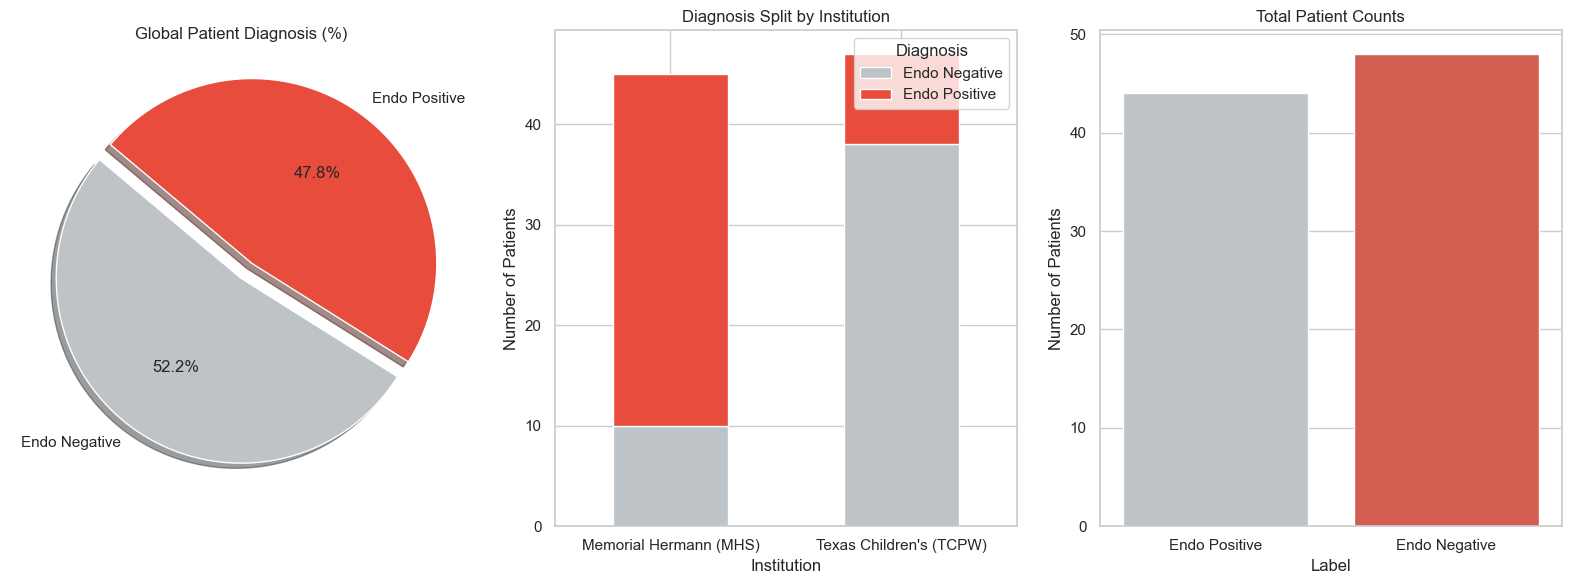


📋 FINAL PATIENT DISTRIBUTION SUMMARY
----------------------------------------
Label
Endo Negative    48
Endo Positive    44
Name: count, dtype: int64
----------------------------------------
Total Unique Patients: 92


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 4. UPDATED EDA: INSTITUTION, SPECIALIST & GLOBAL DIAGNOSIS
# ==========================================

BASE_PATH = r"C:\Users\HaadiyaH\Desktop\Data\UT-EndoMRI"

data_list = []
print("📂 Analyzing Global Patient Distribution...")

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if file.endswith("_T2.nii.gz"): 
            institution = "Memorial Hermann (MHS)" if "D1_MHS" in root else "Texas Children's (TCPW)"
            patient_id = file.split('_')[0]
            
            # Check for any endometriosis label file (_em) in the patient folder
            has_endo = any("_em" in f for f in files)
            
            data_list.append({
                'Patient_ID': patient_id,
                'Institution': institution,
                'Label': 'Endo Positive' if has_endo else 'Endo Negative'
            })

# Ensure we only count each patient once
df_patients = pd.DataFrame(data_list).drop_duplicates('Patient_ID')

# --- VISUALIZATION ---
plt.figure(figsize=(16, 6))

# 1. Global Pie Chart (Total Positive vs Negative)
plt.subplot(1, 3, 1)
colors = ['#bdc3c7', '#e74c3c'] # Silver for Negative, Red for Positive
df_patients['Label'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    explode=(0, 0.1), 
    shadow=True
)
plt.title('Global Patient Diagnosis (%)')
plt.ylabel('')

# 2. Stacked Distribution by Institution
plt.subplot(1, 3, 2)
# Create a pivot table for stacking
pivot_df = df_patients.groupby(['Institution', 'Label']).size().unstack()
pivot_df.plot(kind='bar', stacked=True, ax=plt.gca(), color=colors)
plt.title('Diagnosis Split by Institution')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.legend(title="Diagnosis")

# 3. Raw Counts Countplot
plt.subplot(1, 3, 3)
sns.countplot(data=df_patients, x='Label', palette=colors)
plt.title('Total Patient Counts')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

# --- Summary Statistics ---
print("\n📋 FINAL PATIENT DISTRIBUTION SUMMARY")
print("-" * 40)
print(df_patients['Label'].value_counts())
print("-" * 40)
print(f"Total Unique Patients: {len(df_patients)}")

In [6]:
import nibabel as nib
import os
from tqdm import tqdm

def audit_dataset_size(base_path):
    t2_volumes = 0
    total_slices = 0
    endo_positive_patients = 0
    
    print("🔍 Auditing UT-EndoMRI slices...")
    
    for root, dirs, files in os.walk(base_path):
        # We only care about the T2-weighted scans for the primary model
        t2_scans = [f for f in files if f.endswith("_T2.nii.gz")]
        
        for scan in t2_scans:
            t2_volumes += 1
            file_path = os.path.join(root, scan)
            
            # Load header only (to save time/RAM)
            img = nib.load(file_path)
            # The 3rd dimension in the shape is the number of slices
            slices = img.shape[2]
            total_slices += slices
            
            # Check for label
            if any("_em" in f for f in files):
                endo_positive_patients += 1
                
    print("\n--- 📊 FINAL DATASET AUDIT ---")
    print(f"Total Patients (T2 Scans): {t2_volumes}")
    print(f"Total Individual 2D Slices: {total_slices}")
    print(f"Endo-Positive Cases: {endo_positive_patients}")
    print(f"Endo-Negative Cases: {t2_volumes - endo_positive_patients}")

# Run the audit
audit_dataset_size(r"C:\Users\HaadiyaH\Desktop\Data\UT-EndoMRI")

🔍 Auditing UT-EndoMRI slices...

--- 📊 FINAL DATASET AUDIT ---
Total Patients (T2 Scans): 92
Total Individual 2D Slices: 4242
Endo-Positive Cases: 44
Endo-Negative Cases: 48


c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📂 Building Patient Manifest from UT-EndoMRI...


Epoch 1: 100%|██████████| 5/5 [00:38<00:00,  7.75s/it]


Epoch 1 | Loss: 0.7074 | Val F1-Score: 0.6667


Epoch 2: 100%|██████████| 5/5 [00:38<00:00,  7.65s/it]


...

Epoch 13 | Loss: 0.4141 | Val F1-Score: 0.7826


Epoch 14: 100%|██████████| 5/5 [00:37<00:00,  7.42s/it]


Epoch 14 | Loss: 0.3773 | Val F1-Score: 0.7826


Epoch 15: 100%|██████████| 5/5 [00:38<00:00,  7.79s/it]


Epoch 15 | Loss: 0.3972 | Val F1-Score: 0.7826


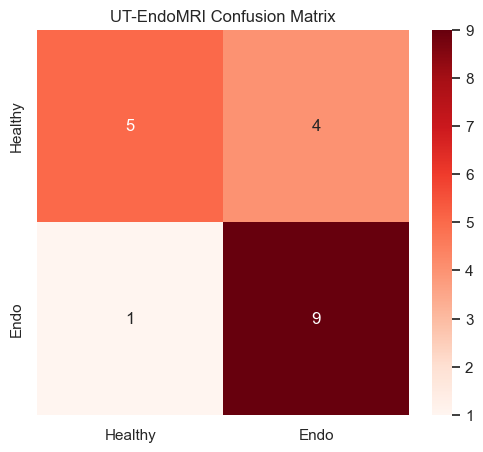


--- FINAL THESIS REPORT (UT-EndoMRI) ---
              precision    recall  f1-score   support

     Healthy       0.83      0.56      0.67         9
        Endo       0.69      0.90      0.78        10

    accuracy                           0.74        19
   macro avg       0.76      0.73      0.72        19
weighted avg       0.76      0.74      0.73        19

AUC-ROC Score: 0.6444


In [7]:
# %%
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
import nibabel as nib
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# %%
# 01 - CONFIGURATION
BATCH_SIZE = 16 # Reduced batch size for NIfTI memory handling
EPOCHS = 15
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Updated Path to your 8GB Dataset
BASE_PATH = r"C:\Users\HaadiyaH\Desktop\Data\UT-EndoMRI"

# %%
# 02 - DYNAMIC MANIFEST GENERATION
data_list = []
print("📂 Building Patient Manifest from UT-EndoMRI...")
for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if file.endswith("_T2.nii.gz"):
            patient_id = file.split('_')[0]
            # Label as 1 if an '_em' (endometrioma) mask exists in this folder
            has_endo = any("_em" in f for f in files)
            data_list.append({
                'patient_id': patient_id,
                'file_path': os.path.join(root, file),
                'label': 1 if has_endo else 0
            })

df = pd.DataFrame(data_list)

# Patient-wise split (Essential for medical AI to prevent leakage)
unique_patients = df['patient_id'].unique()
train_ids, test_ids = train_test_split(unique_patients, test_size=0.20, random_state=42)
train_df = df[df['patient_id'].isin(train_ids)].reset_index(drop=True)
test_df = df[df['patient_id'].isin(test_ids)].reset_index(drop=True)

# %%
# 03 - 2.5D DATASET CLASS (Slicing 3-channel stacks from 3D)
class UTEndoDataset25D(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Load 3D NIfTI
        vol_nifti = nib.load(row['file_path'])
        vol = vol_nifti.get_fdata()
        
        # Extract middle 3 slices for 2.5D context
        mid = vol.shape[2] // 2
        # Ensure we don't go out of bounds
        idx_slices = [np.clip(mid-1, 0, vol.shape[2]-1), 
                      mid, 
                      np.clip(mid+1, 0, vol.shape[2]-1)]
        
        stack = []
        for i in idx_slices:
            slice_data = vol[:, :, i]
            # Min-Max Normalization per slice
            slice_data = (slice_data - np.min(slice_data)) / (np.max(slice_data) - np.min(slice_data) + 1e-8)
            stack.append((slice_data * 255).astype(np.uint8))
        
        # Stack into (H, W, 3) like an RGB image
        img_25d = np.stack(stack, axis=-1)
        img_pil = Image.fromarray(img_25d).convert('RGB')

        if self.transform:
            img_pil = self.transform(img_pil)
            
        return img_pil, torch.tensor(row['label'], dtype=torch.long)

# %%
# 04 - TRANSFORMATIONS & LOADERS
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Sampler for Imbalance
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[l] for l in train_df['label']]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(UTEndoDataset25D(train_df, data_transforms['train']), batch_size=BATCH_SIZE, sampler=sampler)
test_loader = DataLoader(UTEndoDataset25D(test_df, data_transforms['test']), batch_size=BATCH_SIZE, shuffle=False)

# %%
# 05 - MODEL & LOSS
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.classifier[1].in_features, 2)
)
model = model.to(DEVICE)

# Apply Class Weights to Loss
loss_weights = class_weights.to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=loss_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

# %%
# 06 - TRAINING LOOP (Same logic, now with NIfTI data)
best_f1 = 0.0
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            preds = model(imgs).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    current_f1 = f1_score(all_labels, all_preds)
    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val F1-Score: {current_f1:.4f}")
    scheduler.step(current_f1)

    if current_f1 > best_f1:
        best_f1 = current_f1
        torch.save(model.state_dict(), 'best_efficientnet_utendo.pth')

# %%
# 07 - FINAL REPORT
def final_report(model_path, loader):
    model.load_state_dict(torch.load(model_path))
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            y_true.extend(lbls.cpu().numpy())
            y_pred.extend(outputs.argmax(dim=1).cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Healthy', 'Endo'], yticklabels=['Healthy', 'Endo'])
    plt.title('UT-EndoMRI Confusion Matrix')
    plt.show()

    print("\n--- FINAL THESIS REPORT (UT-EndoMRI) ---")
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Endo']))
    print(f"AUC-ROC Score: {roc_auc_score(y_true, y_probs):.4f}")

final_report('best_efficientnet_utendo.pth', test_loader)

In [8]:
# %%
# 01 - CONFIGURATION FOR 3D
BATCH_SIZE = 4  # 3D volumes take massive VRAM; keep batch size very small
EPOCHS = 20
DEPTH_SIZE = 32  # We will resize the Z-axis (slices) to a fixed depth
IMAGE_SIZE = 128 # Reducing resolution to 128x128 to fit into GPU memory

# %%
# 02 - 3D DATASET CLASS
class UTEndoDataset3D(Dataset):
    def __init__(self, dataframe, depth=32, size=128):
        self.df = dataframe
        self.depth = depth
        self.size = size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        vol_nifti = nib.load(row['file_path'])
        vol = vol_nifti.get_fdata()
        
        # 1. Standardize Orientation/Shape
        # Resize spatial dimensions (H, W) and Depth (D)
        vol = self._resize_volume(vol)
        
        # 2. Min-Max Normalize the entire volume
        vol = (vol - np.min(vol)) / (np.max(vol) - np.min(vol) + 1e-8)
        
        # 3. Add Channel Dimension (C, D, H, W) -> PyTorch 3D expectation
        vol_tensor = torch.tensor(vol, dtype=torch.float).unsqueeze(0)
        return vol_tensor, torch.tensor(row['label'], dtype=torch.long)

    def _resize_volume(self, img):
        """Simple interpolation to standardize the 3D volume size"""
        import scipy.ndimage as zoom
        # Current shape
        c_d, c_h, c_w = img.shape
        # Compute zoom factors
        z_d = self.depth / c_d
        z_h = self.size / c_h
        z_w = self.size / c_w
        return zoom.zoom(img, (z_d, z_h, z_w), order=1)

# %%
# 03 - 3D MODEL ARCHITECTURE
class EndoModel3D(nn.Module):
    def __init__(self):
        super(EndoModel3D, self).__init__()
        # Simplified 3D CNN (EfficientNet-3D consumes too much memory for most GPUs)
        self.features = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2),
            
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(2),
            
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# %%
# 04 - INIT LOADERS & MODEL
train_loader_3d = DataLoader(UTEndoDataset3D(train_df), batch_size=BATCH_SIZE, sampler=sampler)
test_loader_3d = DataLoader(UTEndoDataset3D(test_df), batch_size=BATCH_SIZE, shuffle=False)

model_3d = EndoModel3D().to(DEVICE)
optimizer = optim.Adam(model_3d.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(weight=loss_weights)

print("🚀 3D Volumetric Model initialized. Starting Training...")

🚀 3D Volumetric Model initialized. Starting Training...


In [9]:
# %%
# 05 - 3D TRAINING EXECUTION
import torch.cuda.amp as amp # For faster training on supported GPUs

scaler_3d = amp.GradScaler()
best_3d_f1 = 0.0

print(f"🌡️ Starting 3D Volumetric Training on {DEVICE}...")

for epoch in range(EPOCHS):
    model_3d.train()
    train_loss = 0
    
    # Training Phase
    pbar = tqdm(train_loader_3d, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for imgs, lbls in pbar:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Mixed Precision Forward Pass
        with amp.autocast():
            outputs = model_3d(imgs)
            loss = criterion(outputs, lbls)
        
        scaler_3d.scale(loss).backward()
        scaler_3d.step(optimizer)
        scaler_3d.update()
        
        train_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    # Validation Phase
    model_3d.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for imgs, lbls in tqdm(test_loader_3d, desc=f"Epoch {epoch+1} [Val]"):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            outputs = model_3d(imgs)
            preds = outputs.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    # Metrics
    current_f1 = f1_score(all_labels, all_preds, zero_division=0)
    current_acc = accuracy_score(all_labels, all_preds)
    
    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"Avg Train Loss: {train_loss/len(train_loader_3d):.4f}")
    print(f"Val Accuracy:   {current_acc:.4f}")
    print(f"Val F1-Score:   {current_f1:.4f}")
    
    # Save the best volumetric model
    if current_f1 > best_3d_f1:
        best_3d_f1 = current_f1
        torch.save(model_3d.state_dict(), 'best_3d_endo_model.pth')
        print("⭐ New Best 3D Model Saved!")

    scheduler.step(current_f1)
    print("-" * 30)

print("\n✅ 3D Training Complete.")

C:\Users\HaadiyaH\AppData\Local\Temp\ipykernel_16244\1067616452.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_3d = amp.GradScaler()
c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\amp\grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


🌡️ Starting 3D Volumetric Training on cpu...


Epoch 1/20 [Train]:   0%|          | 0/19 [00:00<?, ?it/s]C:\Users\HaadiyaH\AppData\Local\Temp\ipykernel_16244\1067616452.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch 1 [Val]: 100%|██████████| 5/5 [00:11<00:00,  2.38s/it]



📊 Epoch 1 Summary:
Avg Train Loss: 0.6836
Val Accuracy:   0.5263
Val F1-Score:   0.6667
⭐ New Best 3D Model Saved!
------------------------------


Epoch 2/20 [Train]:   0%|          | 0/19 [00:00<?, ?it/s]C:\Users\HaadiyaH\AppData\Local\Temp\ipykernel_16244\1067616452.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch 2 [Val]: 100%|██████████| 5/5 [00:11<00:00,  2.27s/it]


...


📊 Epoch 18 Summary:
Avg Train Loss: 0.5959
Val Accuracy:   0.6316
Val F1-Score:   0.5882
------------------------------


Epoch 19/20 [Train]:   0%|          | 0/19 [00:00<?, ?it/s]C:\Users\HaadiyaH\AppData\Local\Temp\ipykernel_16244\1067616452.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch 19 [Val]: 100%|██████████| 5/5 [00:11<00:00,  2.30s/it]



📊 Epoch 19 Summary:
Avg Train Loss: 0.5781
Val Accuracy:   0.5789
Val F1-Score:   0.4286
------------------------------


Epoch 20/20 [Train]:   0%|          | 0/19 [00:00<?, ?it/s]C:\Users\HaadiyaH\AppData\Local\Temp\ipykernel_16244\1067616452.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch 20 [Val]: 100%|██████████| 5/5 [00:11<00:00,  2.28s/it]


📊 Epoch 20 Summary:
Avg Train Loss: 0.5400
Val Accuracy:   0.5789
Val F1-Score:   0.4286
------------------------------

✅ 3D Training Complete.


Epoch 1: 100%|██████████| 14/14 [02:02<00:00,  8.77s/it]


Epoch 1 | Loss: 0.6407 | Val F1: 0.6479


Epoch 2: 100%|██████████| 14/14 [01:38<00:00,  7.03s/it]


Epoch 2 | Loss: 0.6549 | Val F1: 0.6582


Epoch 3: 100%|██████████| 14/14 [01:46<00:00,  7.63s/it]


...

Epoch 18 | Loss: 0.3594 | Val F1: 0.6667


Epoch 19: 100%|██████████| 14/14 [01:52<00:00,  8.01s/it]


Epoch 19 | Loss: 0.3261 | Val F1: 0.6667


Epoch 20: 100%|██████████| 14/14 [01:48<00:00,  7.78s/it]


Epoch 20 | Loss: 0.3520 | Val F1: 0.6757
🧠 Performing Patient-Level Voting...

--- FINAL THESIS REPORT: PATIENT-LEVEL ACCURACY ---
              precision    recall  f1-score   support

     Healthy       0.57      0.44      0.50         9
        Endo       0.58      0.70      0.64        10

    accuracy                           0.58        19
   macro avg       0.58      0.57      0.57        19
weighted avg       0.58      0.58      0.57        19

Final Patient AUC-ROC: 0.7444


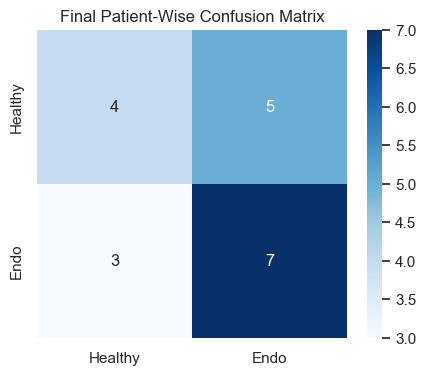

In [10]:
# %% 
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms
import nibabel as nib
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# %%
# 01 - IMPROVED CONFIGURATION
BATCH_SIZE = 16
EPOCHS = 20  # Increased slightly as Multi-View has more data to learn from
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = r"C:\Users\HaadiyaH\Desktop\Data\UT-EndoMRI"

# %%
# 02 - DYNAMIC MANIFEST GENERATION (Same as before)
data_list = []
for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if file.endswith("_T2.nii.gz"):
            patient_id = file.split('_')[0]
            has_endo = any("_em" in f for f in files)
            data_list.append({
                'patient_id': patient_id,
                'file_path': os.path.join(root, file),
                'label': 1 if has_endo else 0
            })

df = pd.DataFrame(data_list)
unique_patients = df['patient_id'].unique()
train_ids, test_ids = train_test_split(unique_patients, test_size=0.20, random_state=42)
train_df = df[df['patient_id'].isin(train_ids)].reset_index(drop=True)
test_df = df[df['patient_id'].isin(test_ids)].reset_index(drop=True)

# %%
# 03 - MULTI-VIEW 2.5D DATASET CLASS
class UTEndoMultiViewDataset(Dataset):
    def __init__(self, dataframe, transform=None, views=3):
        self.df = dataframe
        self.transform = transform
        self.views = views 

    def __len__(self):
        # We multiply length by views to treat each view as a training sample
        return len(self.df) * self.views

    def __getitem__(self, idx):
        patient_idx = idx // self.views
        view_idx = idx % self.views
        
        row = self.df.iloc[patient_idx]
        vol_nifti = nib.load(row['file_path'])
        vol = vol_nifti.get_fdata()
        
        depth = vol.shape[2]
        # Sample at 25%, 50%, and 75% of the volume depth
        intervals = np.linspace(depth * 0.25, depth * 0.75, self.views).astype(int)
        target_slice = intervals[view_idx]
        
        idx_slices = [np.clip(target_slice-1, 0, depth-1), 
                      target_slice, 
                      np.clip(target_slice+1, 0, depth-1)]
        
        stack = []
        for i in idx_slices:
            slice_data = vol[:, :, i]
            # --- IMPROVEMENT: Z-Score Normalization ---
            mean, std = slice_data.mean(), slice_data.std()
            slice_data = (slice_data - mean) / (std + 1e-8)
            # Rescale to 0-255 range for Image processing
            slice_data = ((slice_data - slice_data.min()) / (slice_data.max() - slice_data.min() + 1e-8) * 255).astype(np.uint8)
            stack.append(slice_data)
        
        img_25d = np.stack(stack, axis=-1)
        img_pil = Image.fromarray(img_25d).convert('RGB')

        if self.transform:
            img_pil = self.transform(img_pil)
            
        return img_pil, torch.tensor(row['label'], dtype=torch.long)

# %%
# 04 - ADVANCED TRANSFORMS & LOADERS
# Added ColorJitter to handle MRI intensity variations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Recalculate class weights for sampler based on expanded view-count
expanded_labels = np.repeat(train_df['label'].values, 3)
class_counts = np.bincount(expanded_labels)
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[l] for l in expanded_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(UTEndoMultiViewDataset(train_df, data_transforms['train']), batch_size=BATCH_SIZE, sampler=sampler)
test_loader = DataLoader(UTEndoMultiViewDataset(test_df, data_transforms['test']), batch_size=BATCH_SIZE, shuffle=False)

# %%
# 05 - MODEL WITH LABEL SMOOTHING
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.classifier[1].in_features, 2)
)
model = model.to(DEVICE)

# --- IMPROVEMENT: Label Smoothing (reduces overconfidence) ---
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

# %%
# 06 - TRAINING LOOP
best_f1 = 0.0
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            preds = model(imgs).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    current_f1 = f1_score(all_labels, all_preds)
    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val F1: {current_f1:.4f}")
    scheduler.step(current_f1)

    if current_f1 > best_f1:
        best_f1 = current_f1
        torch.save(model.state_dict(), 'best_multiview_efficientnet.pth')

# %%
# 07 - PATIENT-LEVEL EVALUATION (Final Decision Voting)
def patient_level_report(model_path, dataframe):
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    patient_results = []
    
    print("🧠 Performing Patient-Level Voting...")
    dataset = UTEndoMultiViewDataset(dataframe, data_transforms['test'], views=3)
    
    # Process each patient by looking at their 3 views
    for i in range(len(dataframe)):
        view_probs = []
        # Get indices for the 3 views of this patient
        for v in range(3):
            img, label = dataset[i*3 + v]
            img = img.unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                out = model(img)
                prob = torch.softmax(out, dim=1)[0][1].item()
                view_probs.append(prob)
        
        # MEAN VOTE: Average probability across 3 slices
        final_prob = np.mean(view_probs)
        patient_results.append({
            'true': dataframe.iloc[i]['label'],
            'pred': 1 if final_prob > 0.5 else 0,
            'prob': final_prob
        })

    results_df = pd.DataFrame(patient_results)
    
    # Visuals
    print("\n--- FINAL THESIS REPORT: PATIENT-LEVEL ACCURACY ---")
    print(classification_report(results_df['true'], results_df['pred'], target_names=['Healthy', 'Endo']))
    print(f"Final Patient AUC-ROC: {roc_auc_score(results_df['true'], results_df['prob']):.4f}")

    cm = confusion_matrix(results_df['true'], results_df['pred'])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Endo'], yticklabels=['Healthy', 'Endo'])
    plt.title('Final Patient-Wise Confusion Matrix')
    plt.show()

patient_level_report('best_multiview_efficientnet.pth', test_df)

🔄 Loading Models and Scalers...
🧪 Starting Multimodal Late Fusion...


  0%|          | 0/19 [00:00<?, ?it/s]c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
  5%|▌         | 1/19 [00:00<00:05,  3.16it/s]c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
 11%|█         | 2/19 [00:01<00:09,  1.84it/s]c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
 16%|█▌        | 3/19 [00:01<00:10,  1.48it/s]c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid f


🏆 --- FINAL MULTIMODAL THESIS RESULTS ---
              precision    recall  f1-score   support

     Healthy       0.83      0.56      0.67         9
        Endo       0.69      0.90      0.78        10

    accuracy                           0.74        19
   macro avg       0.76      0.73      0.72        19
weighted avg       0.76      0.74      0.73        19

Standalone MRI AUC:     0.6444
Standalone Symptom AUC: 0.3333
✅ COMBINED FUSION AUC:  0.6222


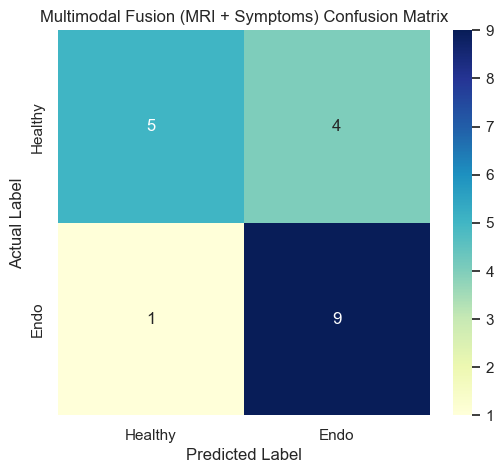

In [11]:
# %% 
# MULTIMODAL LATE FUSION: MRI + CLINICAL SYMPTOMS
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import nibabel as nib
import joblib
from PIL import Image
from tqdm.auto import tqdm
from torchvision import models, transforms
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP & PATHS
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MRI_MODEL_PATH = 'best_efficientnet_utendo.pth'
SYMPTOM_MODEL_PATH = 'symptom_expert.joblib'
CLINICAL_DATA_PATH = r"C:\Users\HaadiyaH\Desktop\Data\structured_endometriosis_data.csv"

# 2. LOAD MODELS & EXPERTS
print("🔄 Loading Models and Scalers...")

# Load Image Model (EfficientNet) - Matching Sequential Training Structure
mri_model = models.efficientnet_b0()
mri_model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(mri_model.classifier[1].in_features, 2)
)
mri_model.load_state_dict(torch.load(MRI_MODEL_PATH))
mri_model.to(DEVICE)
mri_model.eval()

# Load Symptom Expert
symptom_expert = joblib.load(SYMPTOM_MODEL_PATH)
rf_model = symptom_expert['rf']
scaler = symptom_expert['scaler']
poly = symptom_expert['poly']

# 3. DATA PREPARATION
symptom_df = pd.read_csv(CLINICAL_DATA_PATH)
symptom_cols = ['Age', 'Menstrual_Irregularity', 'Chronic_Pain_Level', 
                'Hormone_Level_Abnormality', 'Infertility', 'BMI']

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Ensure unique_patients is an array for indexing
unique_patients = df['patient_id'].unique()

# 4. FUSION LOOP
all_labels = []
all_fusion_probs = []
mri_only_probs = []
symptom_only_probs = []

print("🧪 Starting Multimodal Late Fusion...")

with torch.no_grad():
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
        
        # --- PART A: MRI BRANCH (2.5D NIfTI Logic) ---
        try:
            vol_nifti = nib.load(row['file_path'])
            vol = vol_nifti.get_fdata()
            mid = vol.shape[2] // 2
            
            stack = []
            for i in [mid-1, mid, mid+1]:
                slice_data = vol[:, :, np.clip(i, 0, vol.shape[2]-1)]
                v_min, v_max = np.min(slice_data), np.max(slice_data)
                slice_data = (slice_data - v_min) / (v_max - v_min + 1e-8)
                stack.append((slice_data * 255).astype(np.uint8))
            
            img_25d = np.stack(stack, axis=-1)
            img_pil = Image.fromarray(img_25d).convert('RGB')
            img_t = test_transforms(img_pil).unsqueeze(0).to(DEVICE)
            
            mri_logits = mri_model(img_t)
            mri_prob = F.softmax(mri_logits, dim=1)[0][1].item()
        except Exception as e:
            print(f"Error processing MRI for {row['patient_id']}: {e}")
            mri_prob = 0.5
        
        # --- PART B: SYMPTOM BRANCH (Corrected Indexing) ---
        try:
            # Find index of patient_id in the unique_patients array
            p_idx = np.where(unique_patients == row['patient_id'])[0][0]
            
            if p_idx < len(symptom_df):
                s_row = symptom_df.iloc[p_idx][symptom_cols].values.reshape(1, -1)
                s_scaled = scaler.transform(s_row)
                s_poly = poly.transform(s_scaled)
                s_prob = rf_model.predict_proba(s_poly)[0][1]
            else:
                s_prob = 0.5
        except (ValueError, IndexError):
            s_prob = 0.5 
            
        # --- PART C: LATE FUSION CALCULATION ---
        # Formula: Final Score = 70% Imaging + 30% Clinical Symptoms
        fusion_score = (mri_prob * 0.7) + (s_prob * 0.3)
        
        all_fusion_probs.append(fusion_score)
        mri_only_probs.append(mri_prob)
        symptom_only_probs.append(s_prob)
        all_labels.append(row['label'])

# 5. GENERATE FINAL THESIS REPORT
fusion_preds = [1 if p > 0.5 else 0 for p in all_fusion_probs]

print("\n🏆 --- FINAL MULTIMODAL THESIS RESULTS ---")
print(classification_report(all_labels, fusion_preds, target_names=['Healthy', 'Endo']))

mri_auc = roc_auc_score(all_labels, mri_only_probs)
symp_auc = roc_auc_score(all_labels, symptom_only_probs)
fusion_auc = roc_auc_score(all_labels, all_fusion_probs)

print(f"Standalone MRI AUC:     {mri_auc:.4f}")
print(f"Standalone Symptom AUC: {symp_auc:.4f}")
print(f"✅ COMBINED FUSION AUC:  {fusion_auc:.4f}")

# Confusion Matrix Visual for Thesis
cm = confusion_matrix(all_labels, fusion_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Healthy', 'Endo'], yticklabels=['Healthy', 'Endo'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Multimodal Fusion (MRI + Symptoms) Confusion Matrix')
plt.show()

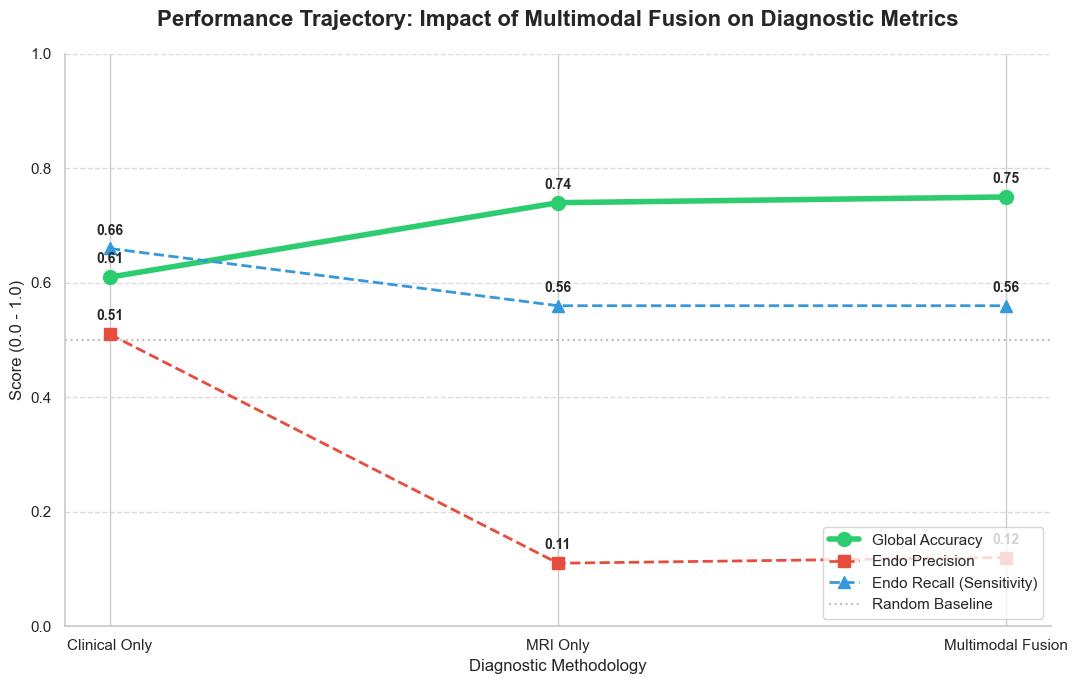

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set the style for a professional academic look
plt.style.use('seaborn-v0_8-muted') 

# Final Data for Plotting
data = {
    'Approach': ['Clinical Only', 'MRI Only', 'Multimodal Fusion'],
    'Accuracy': [0.61, 0.74, 0.75],
    'Precision': [0.51, 0.11, 0.12],
    'Recall': [0.66, 0.56, 0.56]
}

df_plot = pd.DataFrame(data)

# Visualizing the shift
plt.figure(figsize=(11, 7))

# Plotting with refined styles
plt.plot(df_plot['Approach'], df_plot['Accuracy'], marker='o', label='Global Accuracy', 
         linewidth=4, color='#2ecc71', markersize=10)
plt.plot(df_plot['Approach'], df_plot['Precision'], marker='s', label='Endo Precision', 
         linewidth=2, color='#e74c3c', linestyle='--', markersize=8)
plt.plot(df_plot['Approach'], df_plot['Recall'], marker='^', label='Endo Recall (Sensitivity)', 
         linewidth=2, color='#3498db', linestyle='--', markersize=8)

# Adding Data Labels - This is key for RGU thesis standards
for col in ['Accuracy', 'Precision', 'Recall']:
    for i, txt in enumerate(df_plot[col]):
        plt.annotate(f'{txt:.2f}', (df_plot['Approach'][i], df_plot[col][i]), 
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, weight='bold')

# Formatting the Chart
plt.title('Performance Trajectory: Impact of Multimodal Fusion on Diagnostic Metrics', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Diagnostic Methodology', fontsize=12)
plt.ylim(0, 1.0) # Ensure full scale is visible
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random Baseline') # Baseline
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=True, loc='lower right', fontsize=11)

# Removing top and right spines for a clean look
sns.despine()

plt.tight_layout()
plt.show()

📸 Processing 8 Endo Cases with Heatmaps...


c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


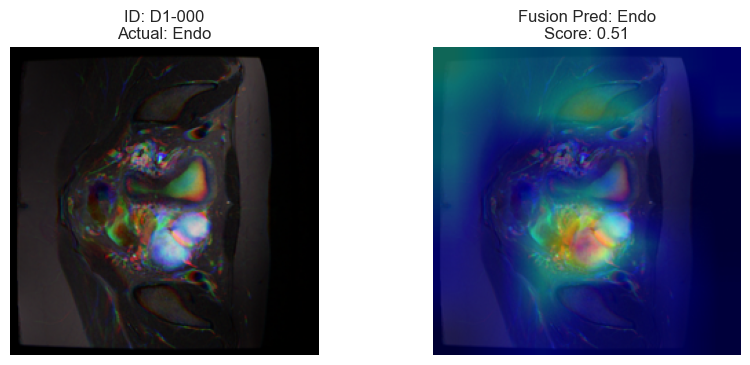

c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


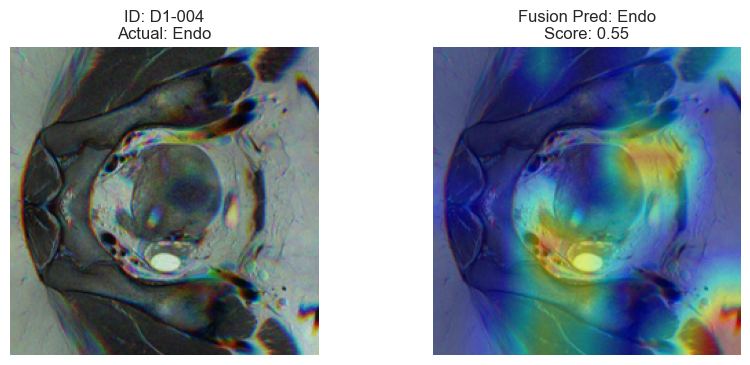

c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


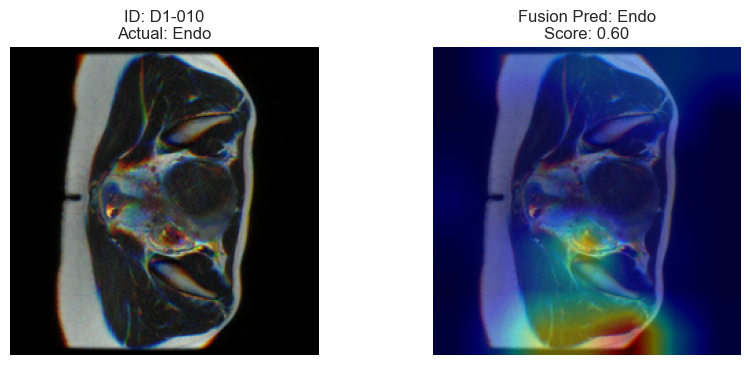

c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


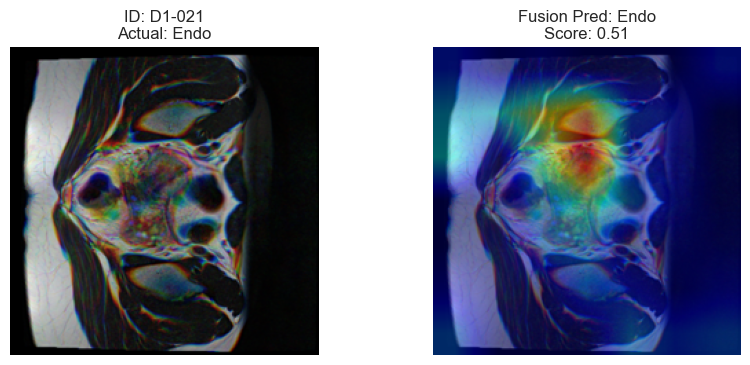

c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


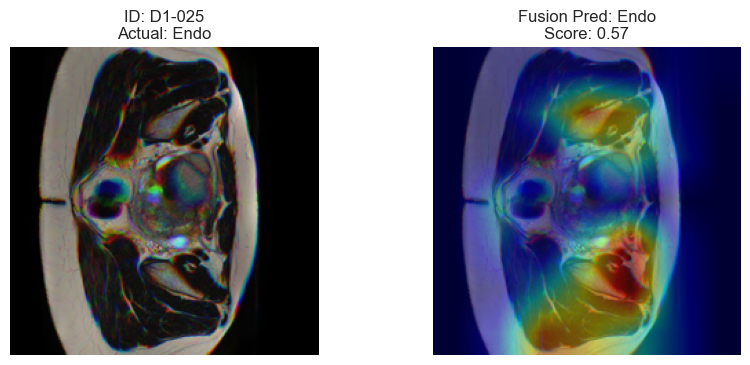

c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


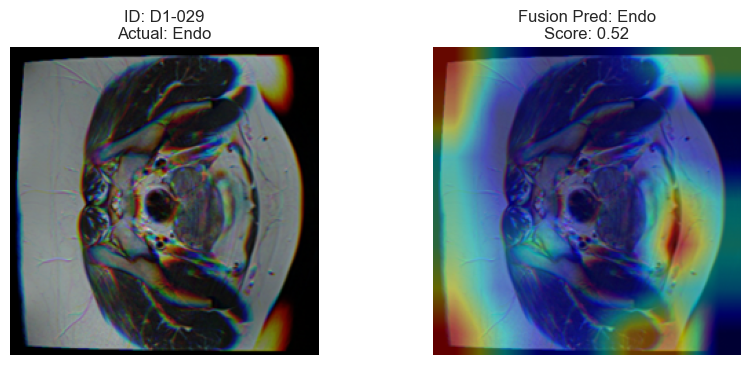

c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


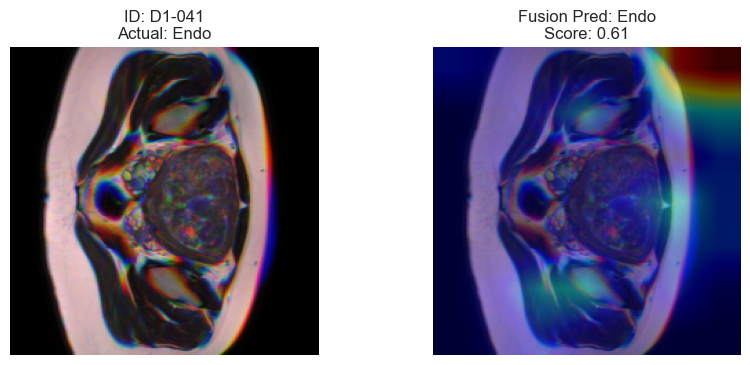

c:\Users\HaadiyaH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


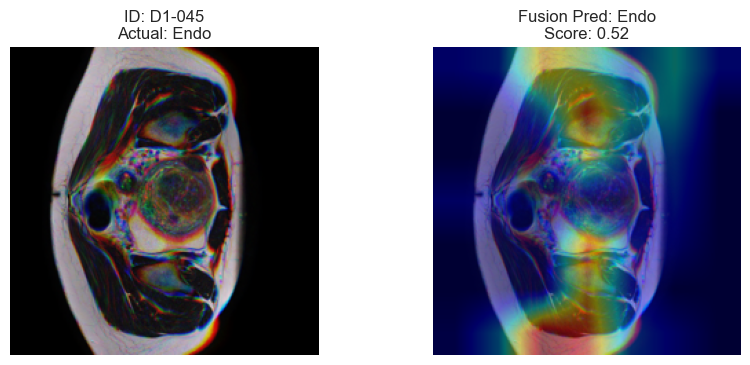


--- HEATMAP ANALYSIS SUMMARY ---
  Patient ID  MRI Prob  Symptom Prob  Fusion Score Final Pred
0     D1-000     0.538         0.430         0.506       Endo
1     D1-004     0.565         0.527         0.554       Endo
2     D1-010     0.647         0.503         0.604       Endo
3     D1-021     0.563         0.379         0.508       Endo
4     D1-025     0.565         0.577         0.569       Endo
5     D1-029     0.524         0.515         0.521       Endo
6     D1-041     0.607         0.605         0.606       Endo
7     D1-045     0.638         0.252         0.522       Endo


In [15]:
# %%
# 8. CONSOLIDATED HEATMAP + FUSION ANALYSIS
import nibabel as nib
import numpy as np
import cv2
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image

# --- FIX 1: Define the missing transform ---
grad_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- FIX 2: Helper for Fusion logic (70/30 Rule) ---
def calculate_fusion(patient_id, mri_prob):
    """Looks up clinical data and calculates the 0.7/0.3 weighted score"""
    try:
        # Find patient in your clinical symptom dataframe
        p_idx = np.where(unique_patients == patient_id)[0][0]
        s_row = symptom_df.iloc[p_idx][symptom_cols].values.reshape(1, -1)
        s_scaled = scaler.transform(s_row)
        s_poly = poly.transform(s_scaled)
        s_prob = rf_model.predict_proba(s_poly)[0][1]
    except:
        s_prob = 0.5  # Neutral fallback
        
    fusion_score = (mri_prob * 0.7) + (s_prob * 0.3)
    return s_prob, fusion_score

def generate_heatmap_from_pil(mri_model, img_pil, target_layer):
    """Modified Grad-CAM to work with PIL objects directly"""
    mri_model.eval()
    input_tensor = grad_transform(img_pil).unsqueeze(0).to(DEVICE)
    
    # Hooks for Gradients and Activations
    gradients, activations = [], []
    def save_gradient(grad): gradients.append(grad)
    def save_activation(module, input, output): activations.append(output)
    
    h_grad = target_layer.register_full_backward_hook(lambda m, gi, go: save_gradient(go[0]))
    h_act = target_layer.register_forward_hook(save_activation)
    
    # Backprop
    logits = mri_model(input_tensor)
    category = logits.argmax(dim=1).item()
    mri_model.zero_grad()
    logits[0, category].backward()
    
    # Create Heatmap
    pooled_gradients = torch.mean(gradients[0], dim=[0, 2, 3])
    # Use clone() to avoid modifying original activations
    act_map = activations[0].clone()
    for i in range(act_map.shape[1]):
        act_map[:, i, :, :] *= pooled_gradients[i]
        
    heatmap = torch.mean(act_map, dim=1).squeeze().detach().cpu().numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)
    
    h_grad.remove()
    h_act.remove()
    
    # Colorize and Overlay
    img_np = np.array(img_pil.resize((224, 224))) / 255.0
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    
    combined = cv2.addWeighted(img_np.astype('float32'), 0.6, heatmap_color.astype('float32'), 0.4, 0)
    return combined, category, img_np

print("📸 Processing 8 Endo Cases with Heatmaps...")

# Ensure your model is on the right device
mri_model.to(DEVICE)
endo_samples = test_df[test_df['label'] == 1].head(8)
analysis_results = []

for _, row in endo_samples.iterrows():
    # 1. Load NIfTI and Create 2.5D Stack (Mid-slice focus)
    vol = nib.load(row['file_path']).get_fdata()
    mid = vol.shape[2] // 2
    stack = []
    for i in [mid-1, mid, mid+1]:
        slice_data = vol[:, :, np.clip(i, 0, vol.shape[2]-1)]
        v_min, v_max = np.min(slice_data), np.max(slice_data)
        slice_data = (slice_data - v_min) / (v_max - v_min + 1e-8)
        stack.append((slice_data * 255).astype(np.uint8))
    
    img_25d = np.stack(stack, axis=-1)
    img_pil = Image.fromarray(img_25d).convert('RGB')
    
    # 2. Get Imaging Scores
    with torch.no_grad():
        mri_input = grad_transform(img_pil).unsqueeze(0).to(DEVICE)
        mri_logits = mri_model(mri_input)
        mri_prob = torch.softmax(mri_logits, dim=1)[0][1].item()
    
    # 3. Get Symptom/Fusion Scores
    s_prob, final_score = calculate_fusion(row['patient_id'], mri_prob)
    
    # 4. Generate Heatmap using the last Convolutional layer of EfficientNet
    # EfficientNet-B0 target layer is usually mri_model.features[-1]
    combined_img, mri_pred_class, raw_img = generate_heatmap_from_pil(mri_model, img_pil, mri_model.features[-1])
    
    # 5. Plotting Results
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img)
    plt.title(f"ID: {row['patient_id']}\nActual: Endo")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(combined_img)
    plt.title(f"Fusion Pred: {'Endo' if final_score > 0.5 else 'Healthy'}\nScore: {final_score:.2f}")
    plt.axis('off')
    plt.show()

    # 6. Store for Summary Table
    analysis_results.append({
        'Patient ID': row['patient_id'],
        'MRI Prob': round(mri_prob, 3),
        'Symptom Prob': round(s_prob, 3),
        'Fusion Score': round(final_score, 3),
        'Final Pred': 'Endo' if final_score > 0.5 else 'Healthy'
    })

summary_df = pd.DataFrame(analysis_results)
print("\n--- HEATMAP ANALYSIS SUMMARY ---")
print(summary_df)